<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%94%D0%97_Lite_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B8_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Возьмите из ноутбука по практическому занятия "Автокодировщики" сверточный вариационный энкодер и обучите его на датасете Emnist letters. Датасет содержит изображения рукописных латинских букв. Размер обучающей выборки 124800 изображенй, тестовой - 20800. Установите размер скрытого пространства равным 2.

В работе:
1. Выведите график использование скрытого пространства АЕ на всех классах датасета.
2. Выведите примеры генерации букв декодером.
3. Выведите примеры восстановления букв автокодировщиком.

**! Установим требуемые библиотеки, потребуется перезапуск среды !**

In [ ]:
#!pip install tensorflow==2.15

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found existing installation

In [1]:
# Установим модуль для загрузки EMNIST
!pip install emnist

In [2]:
# Подключим Numpy
import numpy as np

# Подключим библиотеку отображения графиков
import matplotlib.pyplot as plt

# Импортируем Keras
from tensorflow import keras

import tensorflow as tf

# Подключим все необходимые слои Keras
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Lambda, LeakyReLU
from tensorflow.keras.layers import BatchNormalization, Dropout, concatenate, Conv2D, Conv2DTranspose

# Подключим модуль вычислений на Keras
import keras.backend as K

# Подключим датасет рукописных букв
import emnist
from emnist import extract_training_samples, extract_test_samples

# Подключим модуль работы с операционной системой
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # От tensorflow будет получать только ошибки

In [3]:
emnist.SOURCE_URLS[1] = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'

In [27]:
hidden_dim = 2  # Зададим размерность скрытого пространства AE
batch_size = 100 # Задамим размер батча для обучения AE
num_classes = 27

In [5]:
# Скачаем обучающую выборку
xs_train, y_train = extract_training_samples('letters')

# Скачаем тестовую выборку
xs_test, y_test = extract_test_samples('letters')

# Добавим 1 размерность numpy-массиву обучающей выборки + приведем к диапазону 0...1
x_train = np.reshape(xs_train, (len(xs_train), 28, 28, 1))/255.

# Добавим 1 размерность numpy-массиву тестовой выборки + приведем к диапазону 0...1
x_test = np.reshape(xs_test, (len(xs_test), 28, 28, 1))/255.

In [6]:
# Создадим функцию вывод 100 элементов обучающей выборки

def showResult(viz):                                                  # Получим набор изображений

    total = 10                                                        # Полное количесво выводимых цифр
    plt.figure(figsize=(total, total))                                # Создаем заготовку для финальной картинки
    num = 1                                                           # Счетчик выводимых цифр
    for i in range(0, 100):                                           # Цикл по графикам
        ax = plt.subplot(total, total, num)                           # Добавим место для графика
        img = viz[num-1,:,:,:]                                        # Вывыбираем очередной график
        num += 1                                                      # Инкремент номера графика
        plt.imshow(img.squeeze(), cmap='gray')                        # Рисуем предсказанную цифру
        ax.get_xaxis().set_visible(False)                             # Спрячем ось X
        ax.get_yaxis().set_visible(False)                             # Спрячем ось Y

# Определим функцию отображения результатов работы декодера

def showResult2(decoder): # Получим обученный декодер

    n = 5
    total = 2*n+1                                                     # Считаем полное количесво выводимых цифр +1
    plt.figure(figsize=(total, total))                                # Создаем заготовку для финальной картинки
    num = 1                                                           # Счетчик выводимых цифр
    for i in range(-n, n+1):                                          # Цикл по горизонтали пространства Z
     for j in range(-n, n+1):                                         # Цикл по вертикали пространства Z
        ax = plt.subplot(total, total, num)                           # Добавим место для графика
        num += 1                                                      # Инкремент номера графика
        img = decoder.predict(np.expand_dims([3*i/n, 3*j/n], axis=0)) # Выполним предикт изображения цифры по точкам из Z области
        plt.imshow(img.squeeze(), cmap='gray')                        # Рисуем предсказанную цифру
        ax.get_xaxis().set_visible(False)                             # Спрячем ось X
        ax.get_yaxis().set_visible(False)                             # Спрячем ось Y

In [7]:
print (x_train.shape) # Выведем размерность обучающей выборки изображений
print (x_test.shape)  # Выведем размерность тестовой выборки изображений
print (y_train.shape) # Выведем размерность обучающей выборки меток
print (y_test.shape)  # Выведем размерность тестовой выборки меток


(124800, 28, 28, 1)
(20800, 28, 28, 1)
(124800,)
(20800,)


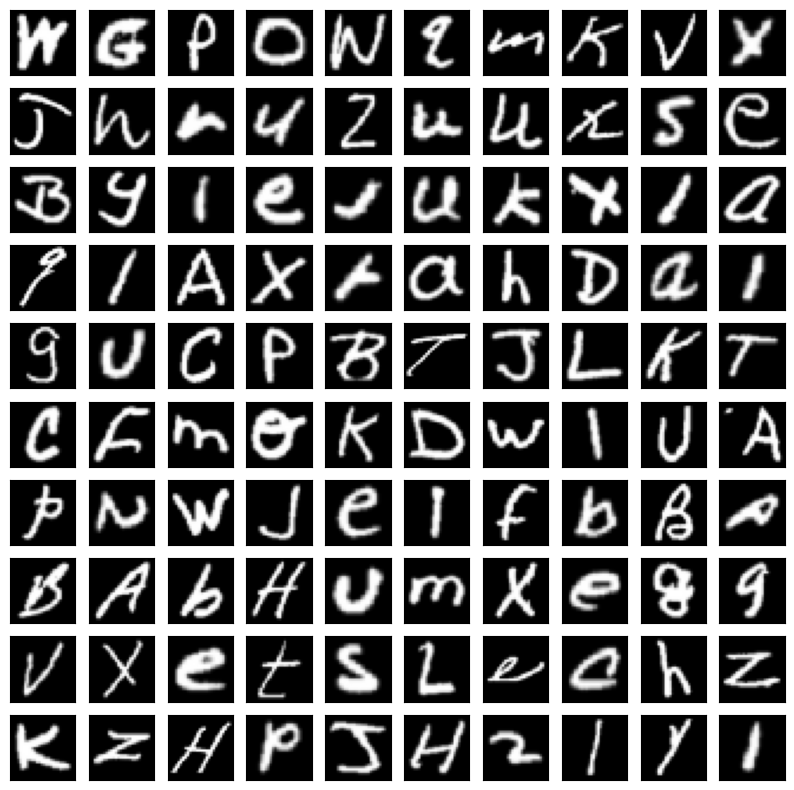

In [8]:
# Взглянем на первые 100 изображений обучающей выборки

showResult(x_train[:100,:,:,:])

In [9]:
# Взглянем на первые 100 меток обучающей выборки

y_train[:100]

array([23,  7, 16, 15, 23, 17, 13, 11, 22, 24, 10, 14, 18, 21, 26, 21, 21,
       24, 19,  5,  2, 25,  9,  5, 10, 21, 11, 24, 12,  1, 17,  9,  1, 24,
       18,  1,  8,  4,  1,  9,  7, 21,  3, 16,  2, 20, 10, 12, 11, 20,  3,
        6, 13, 15, 11,  4, 23, 12, 21,  1, 16, 14, 23, 10,  5, 12,  6,  2,
        2,  1,  2,  1,  2,  8, 21, 13, 24,  5,  7,  7, 22, 24,  5, 20, 19,
       12,  5,  3,  8, 26, 11, 26,  8, 16, 10,  8, 26, 12, 25,  9],
      dtype=uint8)

In [10]:
# Ваше решение

# Функция создания блока энкодера-декодера

def dropout_and_batch(xin): # xin - входной тензор

  x = BatchNormalization()(xin) # Добавим слой нормализации
  x = Dropout(0.3)(x)           # Добавим дроаут

  # Вернем выходной тензор
  return x

In [11]:
#  Создадим энкодер

input_img = Input((28, 28, 1))       # Добавим входной слой
x = Flatten()(input_img)             # Добавим Flatten
x = Dense(256, activation='relu')(x) # Добавим dense на 256 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация
x = Dense(128, activation='relu')(x) # Добавим dense на 128 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация

In [12]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для логарифма дисперсии

In [13]:
import keras
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [14]:
# Соберем энкодер

encoderVAE = keras.Model(input_img, [z_mean, z_log_var, h], name='encoder')

In [15]:
#  Создадим декодер

input_dec = Input(shape=(hidden_dim,))      # Добавим входной слой
d = Dense(128, activation='relu')(input_dec)# Добавим 1й dense
d = dropout_and_batch(d)                    # Добавим 1й блок дропаут+нормализация
d = Dense(256, activation='relu')(d)        # Добавим 2й dense
d = dropout_and_batch(d)                    # Добавим 2й блок дропаут+нормализация
d = Dense(28*28, activation='sigmoid')(d)   # Добавим выходной dense
decoded = Reshape((28, 28, 1))(d)           # Решейпим до исходной размерности картинки

In [16]:
# Соберем декодер

decoderVAE = keras.Model(input_dec, decoded, name='decoder')

In [18]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderVAE(encoderVAE(input_img)[2])    # Заметим, что на только 1 из 3х выходов энкодера будем использовать

In [19]:
# Соберем наши сетки

vae = keras.Model(input_img, outputs, name="vae")

In [20]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
vae = keras.Model(input_img, outputs)

In [21]:
 # Компилируем VAE

vae.compile(optimizer='adam')

In [22]:
# Запускаем обучениe

vae.fit(x_train,       # Обучающая выборка
        x_train,       # "Labels" обучающей выборки
        epochs=15,      # 15 эпох
        batch_size=60, # размер батча
        shuffle=True)  # обучающую выборку перемешиваем

Epoch 1/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 83.1621
Epoch 2/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 56.8223
Epoch 3/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 55.9271
Epoch 4/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 55.4138
Epoch 5/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 55.0281
Epoch 6/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.7062
Epoch 7/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.5130
Epoch 8/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.4019
Epoch 9/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 54.2069
Epoch 10/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.0495
Epoch 11/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 53.9762
Epoch 12/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 53.8271
Epoch 13/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 53.7795
Epoch 14/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 53.7030
Epoch 15/15
20

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


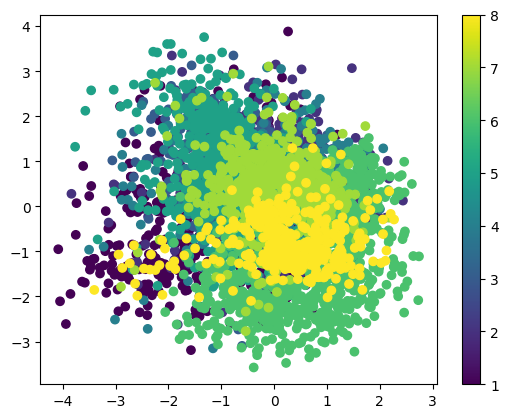

In [23]:
#Смотрим на точки в скрытом пространстве:
h = encoderVAE.predict(x_test[:6000], batch_size=batch_size)          # Предиктим энкодером первые 6000 цизображений ифр

plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                        # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()

In [24]:
# Добавим 1 размерность numpy-массиву обучающей выборки
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

In [25]:
y_train_cat = keras.utils.to_categorical(y_train)
y_test_cat = keras.utils.to_categorical(y_test)

In [28]:
# Создадим простой энкодер

input_img = Input((28, 28, 1))       # Добавим входной слой
fl = Flatten()(input_img)             # Добавим Flatten
lb = Input(shape=(num_classes,))     # Добавим входной слой для метки класса
x = concatenate([fl, lb])            # конкатенируем метку класса изображение
x = Dense(256, activation='relu')(x) # Добавим dense на 256 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация
x = Dense(128, activation='relu')(x) # Добавим dense на 128 нейронов
x = dropout_and_batch(x)             # Добавим блок дропаут + нормализация

In [29]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для получения мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для получения логарифма дисперсии

In [30]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [31]:
# Соберем энкодер

encoderCVAE = keras.Model([input_img, lb], [z_mean, z_log_var, h], name='encoder')

In [32]:


#  Создадим декодер

input_dec = Input(shape=(hidden_dim,))      # Добавим входной слой
lb_dec = Input(shape=(num_classes,))        # Добавим вход для метки класса
d = concatenate([input_dec, lb_dec])        # Конкатенируем метку класса и вектор скрытого пространства
d = Dense(128, activation='relu')(d)        # Добавим 1й dense
d = dropout_and_batch(d)                    # Добавим 1й блок дропаут+нормализация
d = Dense(256, activation='relu')(d)        # Добавим 2й dense
d = dropout_and_batch(d)                    # Добавим 2й блок дропаут+нормализация
d = Dense(28*28, activation='sigmoid')(d)   # Добавим выходной dense
decoded = Reshape((28, 28, 1))(d)           # Решейпим до исходной размерности картинки

In [33]:

# Соберем декодер

decoderCVAE = keras.Model([input_dec, lb_dec], decoded, name='decoder')

In [34]:

# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderCVAE([encoderCVAE([input_img, lb])[2], lb_dec])

In [35]:
#Соберем наши CVAE
cvae = keras.Model([input_img, lb, lb_dec], outputs , name="cvae") # Соберем VAE

# Соберем вспомогательную модель
z_meaner = keras.Model([input_img, lb], z_mean)

# Соберем модель для переноса стиля
tr_style = keras.Model([input_img, lb, lb_dec], decoderCVAE([z_meaner([input_img, lb]), lb_dec]), name='tr_style')

In [36]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
cvae = keras.Model([input_img, lb, lb_dec], outputs)

In [37]:
# Компилируем VAE

cvae.compile(optimizer='adam') # оптимайзер ADAM

In [38]:
# Обучим модель

cvae.fit([x_train, y_train_cat, y_train_cat],  # Обучающая выборка + метки классов для энкодера и декодера
         x_train,                              # Обучающая выборка
         epochs=15,                            # Число эпох
         batch_size=batch_size,                # Размер батча
         shuffle=True)                         # Обучающую выборку перемешиваем

Epoch 1/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 91.6451
Epoch 2/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 50.2641
Epoch 3/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 48.3840
Epoch 4/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 47.4520
Epoch 5/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 46.6357
Epoch 6/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 46.0516
Epoch 7/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 45.5099
Epoch 8/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 45.2455
Epoch 9/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 44.9256
Epoch 10/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 44.6272
Epoch 11/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 44.3970
Epoch 12/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 44.1903
Epoch 13/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 44.1256
Epoch 14/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 43.8674
Epoch 15/15
12

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


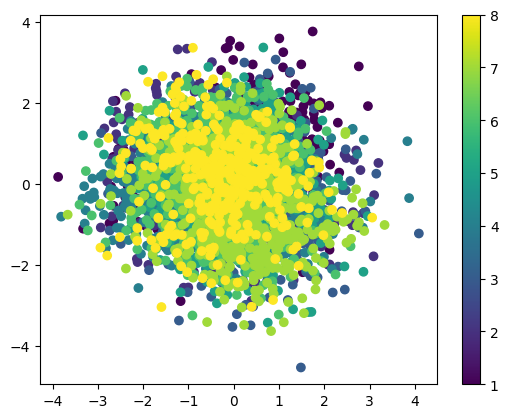

In [39]:
lb = lb_dec = y_test_cat                                                   # Копия меток классов
h = encoderCVAE.predict([x_test[:6000], lb[:6000]], batch_size=batch_size) # Предиктим точки скрытого пространства с учетом меток

plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis')        # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                               # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

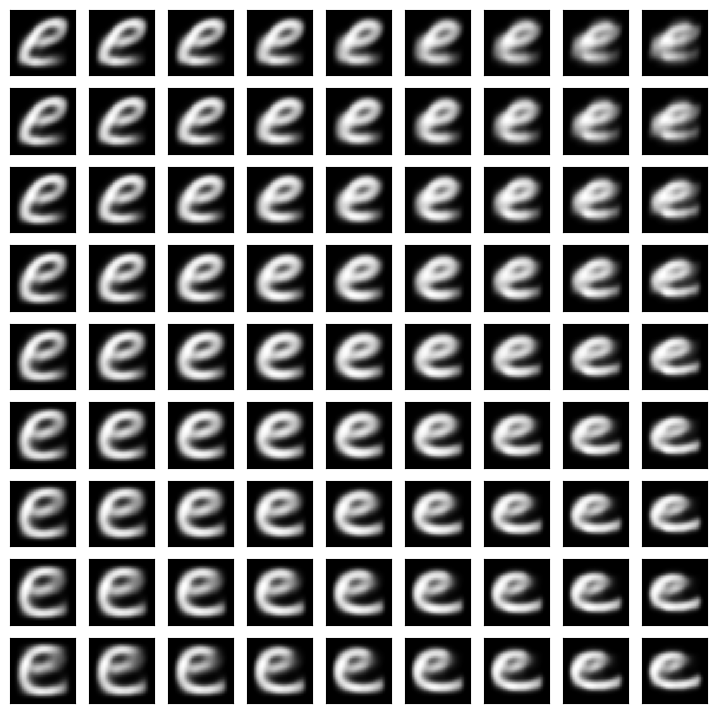

In [40]:
# Генерим разные E

n = 4                                      # Просто нужная переменная
total = 2*n+1                              # Считаем общий размер картинки
input_lbl = np.zeros((1, num_classes))     # Заготовим массов из нулей, размерности = числу классов
input_lbl[0, 5] = 1                        # В пятый элемент запишем 1
plt.figure(figsize=(total, total))         # Заготовим общую картинку
h = np.zeros((1, hidden_dim))              # Заготовим массов из нулей, размерности = скрытого пространства
num = 1                                    # Создаем счетчик картинок

for i in range(-n, n+1):                   # Цикл по горизонтали
  for j in range(-n, n+1):                 # Цикл по вертикали
    ax = plt.subplot(total, total, num)    # Заготовим отдельную картинку для цифры
    num += 1                               # Инкрементируем счетчик картинок
    h[0, :] = [1*i/n, 1*j/n]               # Создадим точку из скрытого пространство
    img = decoderCVAE.predict([h, input_lbl])  # Предиктим цифру 5,  соответсвующую точке скрытого пространства
    plt.imshow(img.squeeze(), cmap='gray') # Отрисуем полученную цифру
    ax.get_xaxis().set_visible(False)      # Уберем ось X
    ax.get_yaxis().set_visible(False)      # Уберем ось Y

In [41]:
# Создадим функцию для отрисовки линейки картинок

def plot_digits(*images): # Список картинок

    images = [x.squeeze() for x in images]               # Понизим размерности картинок
    n = min([x.shape[0] for x in images])                # Найдем число картинок
    plt.figure(figsize=(n, len(images)))                 # Заготовим общее изображение
    for j in range(n):                                   # Цикл по
        for i in range(len(images)):                     # Цикл по списку картинок
            ax = plt.subplot(len(images), n, i*n + j + 1)# Заготовим картинку
            plt.imshow(images[i][j])                     # Отрисуем ее
            plt.gray()                                   # Рисуем в градациях серого
            ax.get_xaxis().set_visible(False)            # Уберем ось X
            ax.get_yaxis().set_visible(False)            # Уберем ось Y

    plt.show()                                           # Отрисуем итоговую картиную

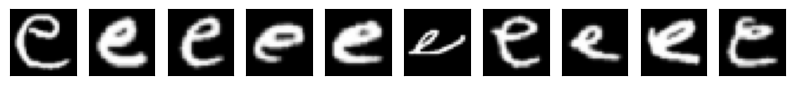

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step


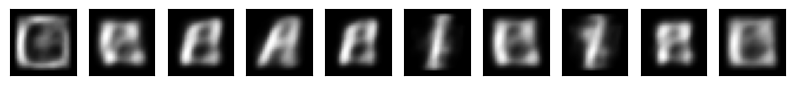

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


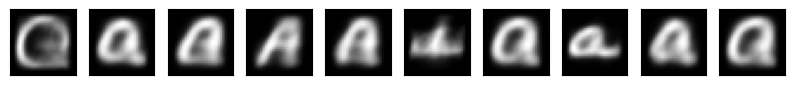

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


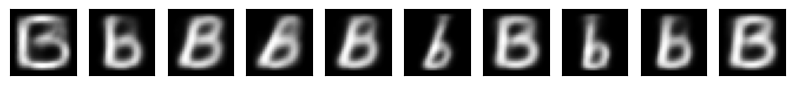

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


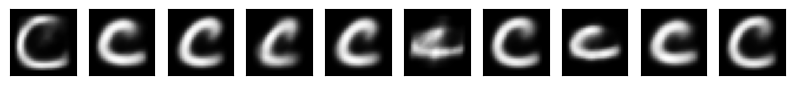

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


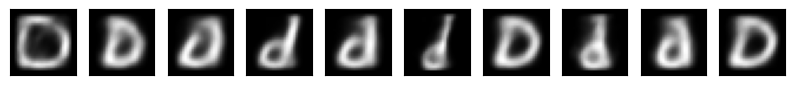

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


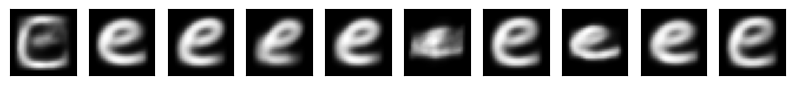

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


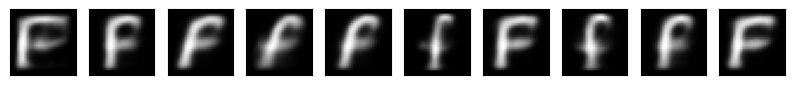

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


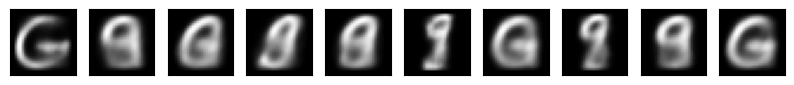

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


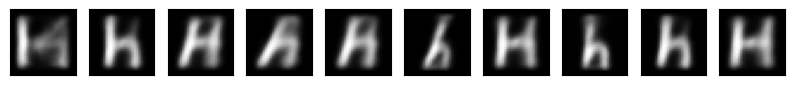

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


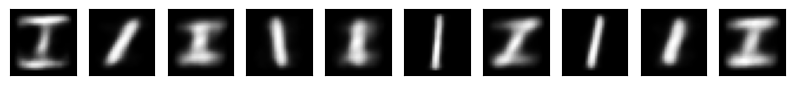

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


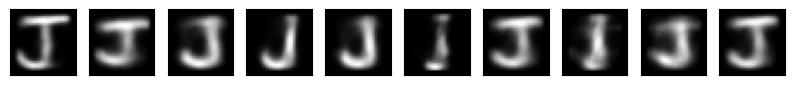

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


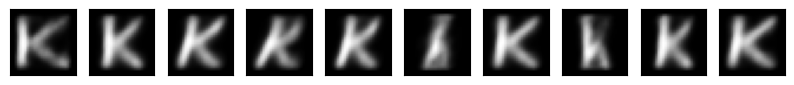

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


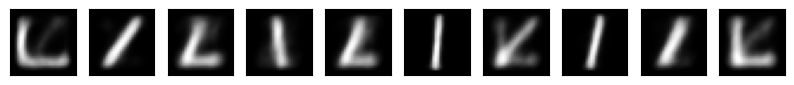

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


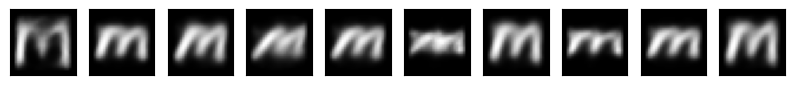

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


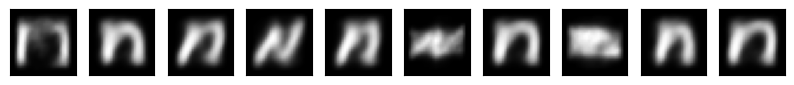

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


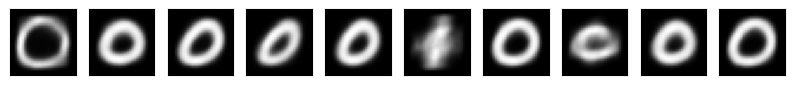

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


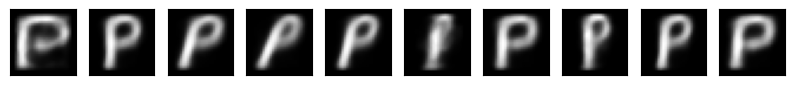

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


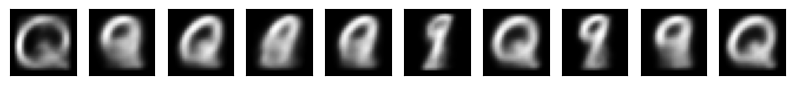

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


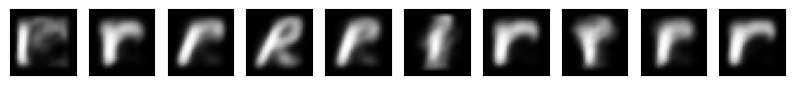

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


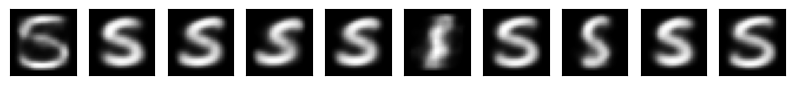

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


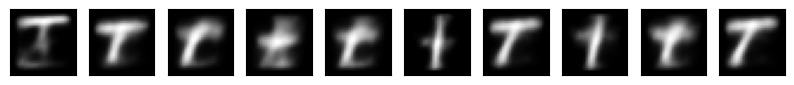

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


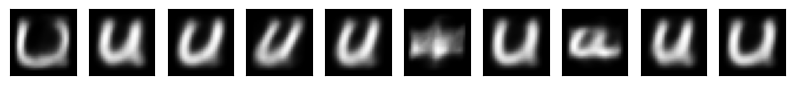

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


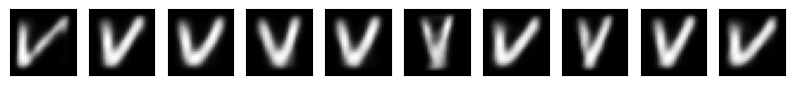

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


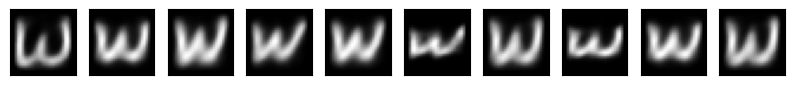

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


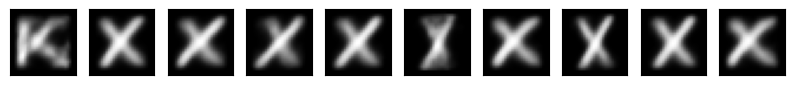

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


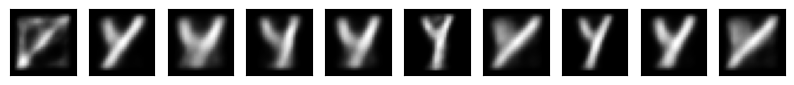

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


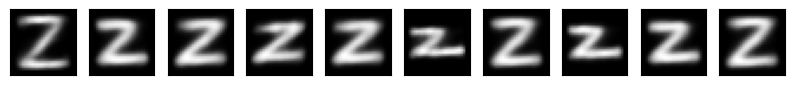

In [42]:
# Выберем Буквы - источник
dig1 = 5

# Выберем число образцов
num = 10

# Отберем образцы стилей
X = x_train[y_train == dig1][:num]

# Создадим массив из нулей
lb_1 = np.zeros((num, num_classes))

# Заполним 5-ю колонку E
lb_1[:, dig1] = 1

# Отрисуем образцы стилей
plot_digits(X)

# Цикл по всем возможным классам букв
for i in range(num_classes):

  lb_2 = np.zeros((num, num_classes)) # Создадим массив из нулей
  lb_2[:, i] = 1                      # Заполним i-ю колонку единицами

  Y = tr_style.predict([X, lb_1, lb_2], batch_size=num) # Выполним предикт
  plot_digits(Y)                                        # Отрисуем полученные цифры

In [43]:
cvae.save('cvae.keras')

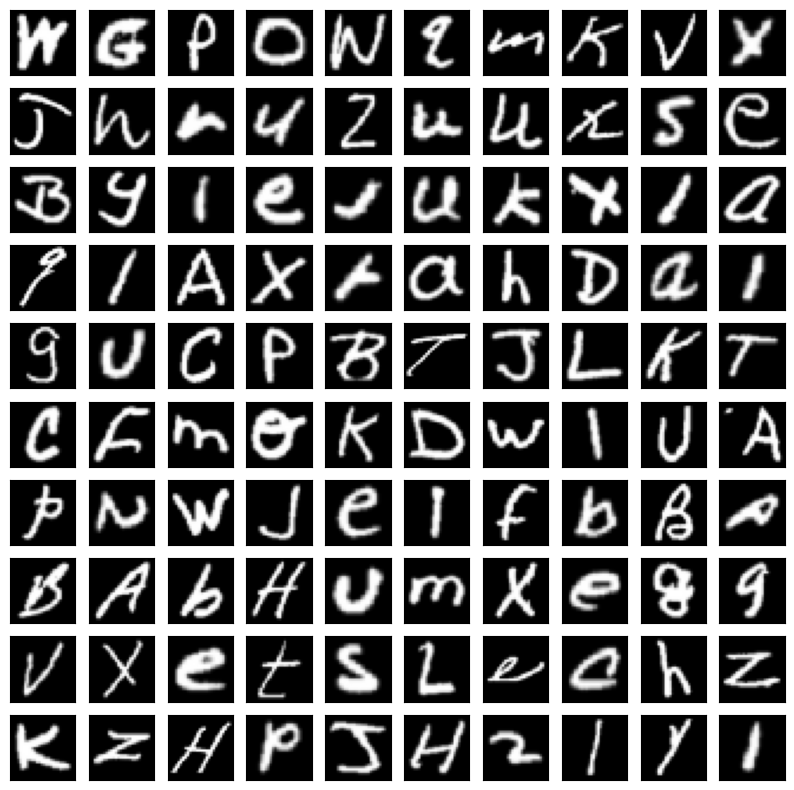

In [44]:
showResult(x_train[:100,:,:,:])

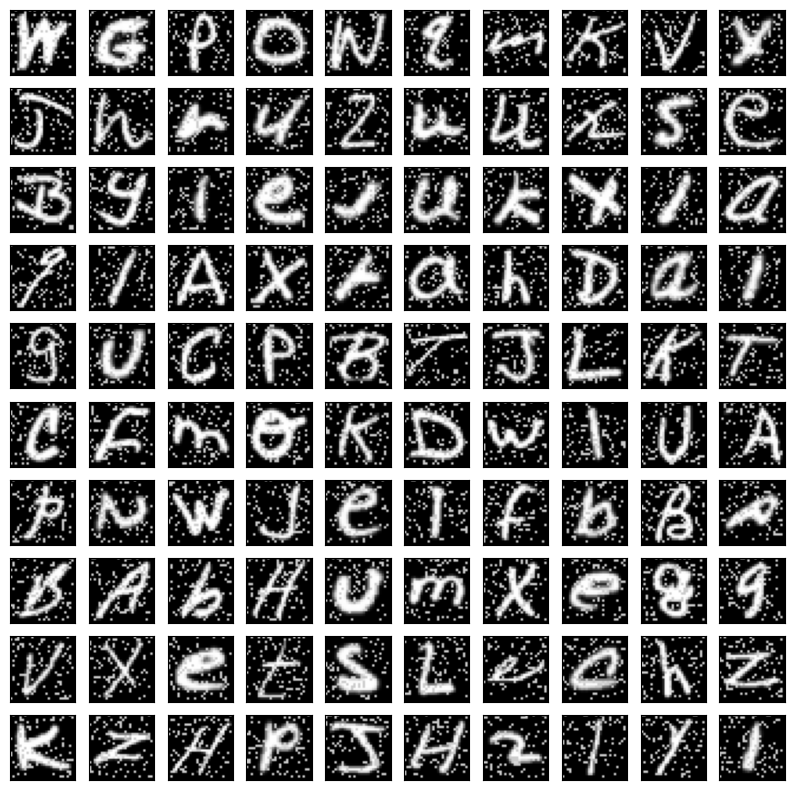

In [45]:
x_train_noised = x_train[0:100]
for i in range(0, len(x_train_noised)):
    for j in range(0, 100):
        row = np.random.randint(0, 27)
        col = np.random.randint(0, 27)
        x_train_noised[i][col][row][0] = 0.8
showResult(x_train_noised)

In [46]:
x_train_noised.shape
y_train.shape
num = 100
lb_2 = np.zeros((num, num_classes)) # Создадим массив из нулей
for i in range(0, len(x_train_noised)):
    lb_2[i, y_train[i]] = 1                      # Заполним i-ю колонку единицами

print(lb_2[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0.]


In [47]:
x_train_recovered = cvae.predict([x_train_noised, lb_2, lb_2], batch_size=32)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step


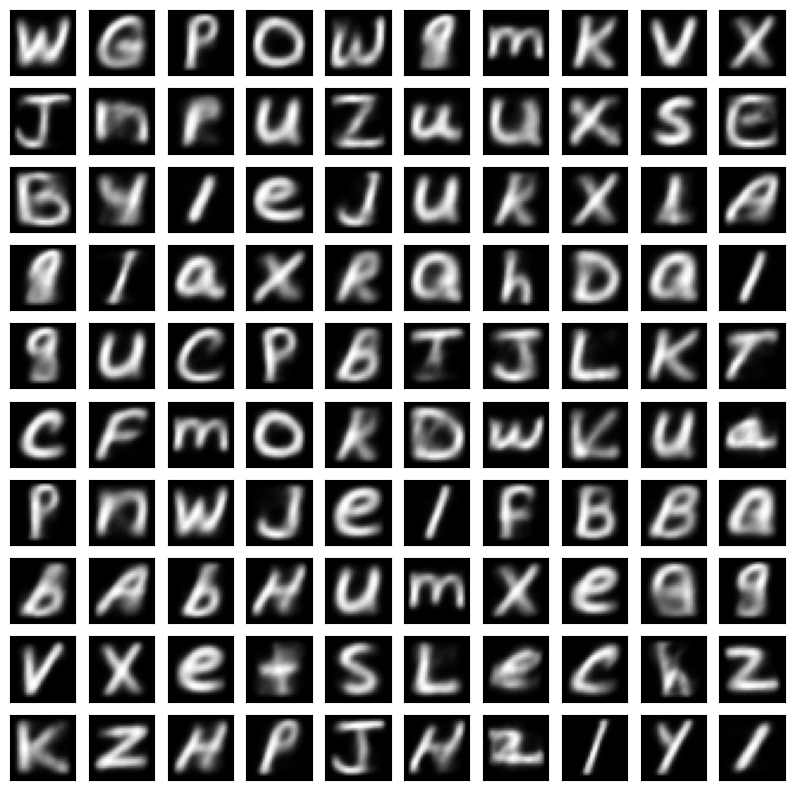

In [48]:
showResult(x_train_recovered)